##### Imports

In [1]:
# %pip install -r requirements.txt

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from scipy.stats import norm, invgamma, multivariate_normal
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

warnings.filterwarnings('ignore')

# Loading Saved Model

In [3]:
# Create DataFrame of asset names
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'Investment Universe ETFs': get_assets_by_class('universe') + ['']*7,
    'US Equity ETFs': get_assets_by_class('us_equity'),
    'Commodities': get_assets_by_class('commodity') + ['']*5,
    'International Equity ETFs': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,Investment Universe ETFs,US Equity ETFs,Commodities,International Equity ETFs
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


LOADED MODEL INFORMATION

2. KAMA PARAMETERS:
----------------------------------------
KAMA n: 8
KAMA n_fast: 11
    KAMA k_fast: 0.166667
KAMA n_slow: 33
    KAMA k_slow: 0.058824
gamma: 0.85

3. MSR PRIORS:
----------------------------------------
mean_prior_mean: 0.0
mean_prior_var: 0.1
beta_prior_mean: 0.0
beta_prior_var: 1.0
sigma_prior_shape: 2.0
sigma_prior_scale: 0.1
transition_prior_alpha: 8.0

4. MODEL CONFIGURATION:
----------------------------------------
use_three_state_msr: False
Number of combined regimes: 4
MSR n_regimes: 2

5. DATA INFORMATION:
----------------------------------------
Price data length: 5038
Return data length: 5037
Regime labels length: 5029
Regime changes: 101

6. MSR PARAMETERS (Post-Fit):
----------------------------------------
MSR Means (μ):
  Regime 0: 0.000639
  Regime 1: -0.001955

MSR Betas (β):
  Regime 0: -0.0066
  Regime 1: -0.0226

MSR Standard Deviations (σ):
  Regime 0: 0.012799
  Regime 1: 0.032278

MSR Transition Probabilities:
      

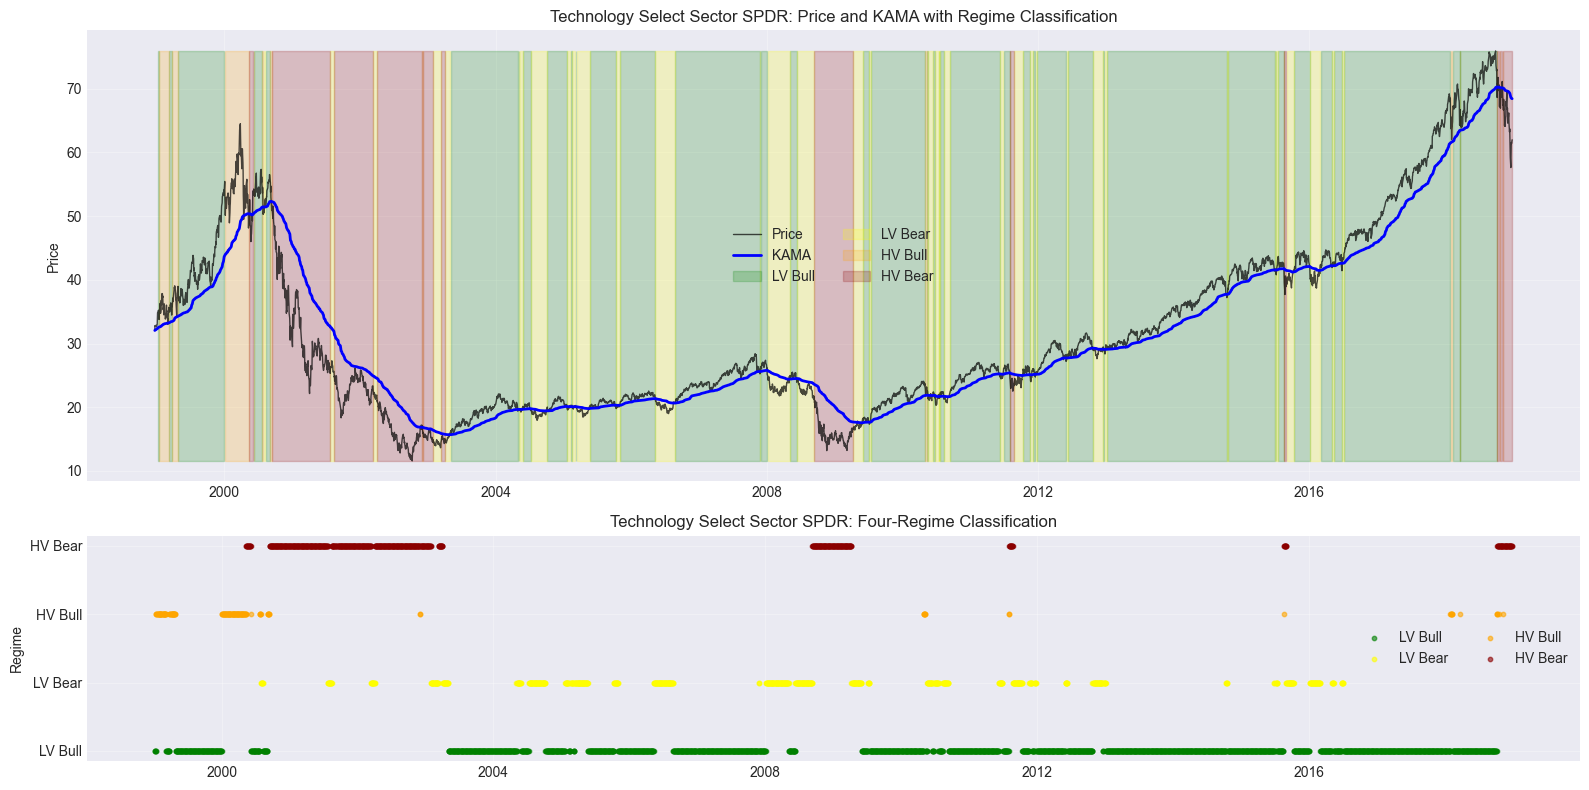

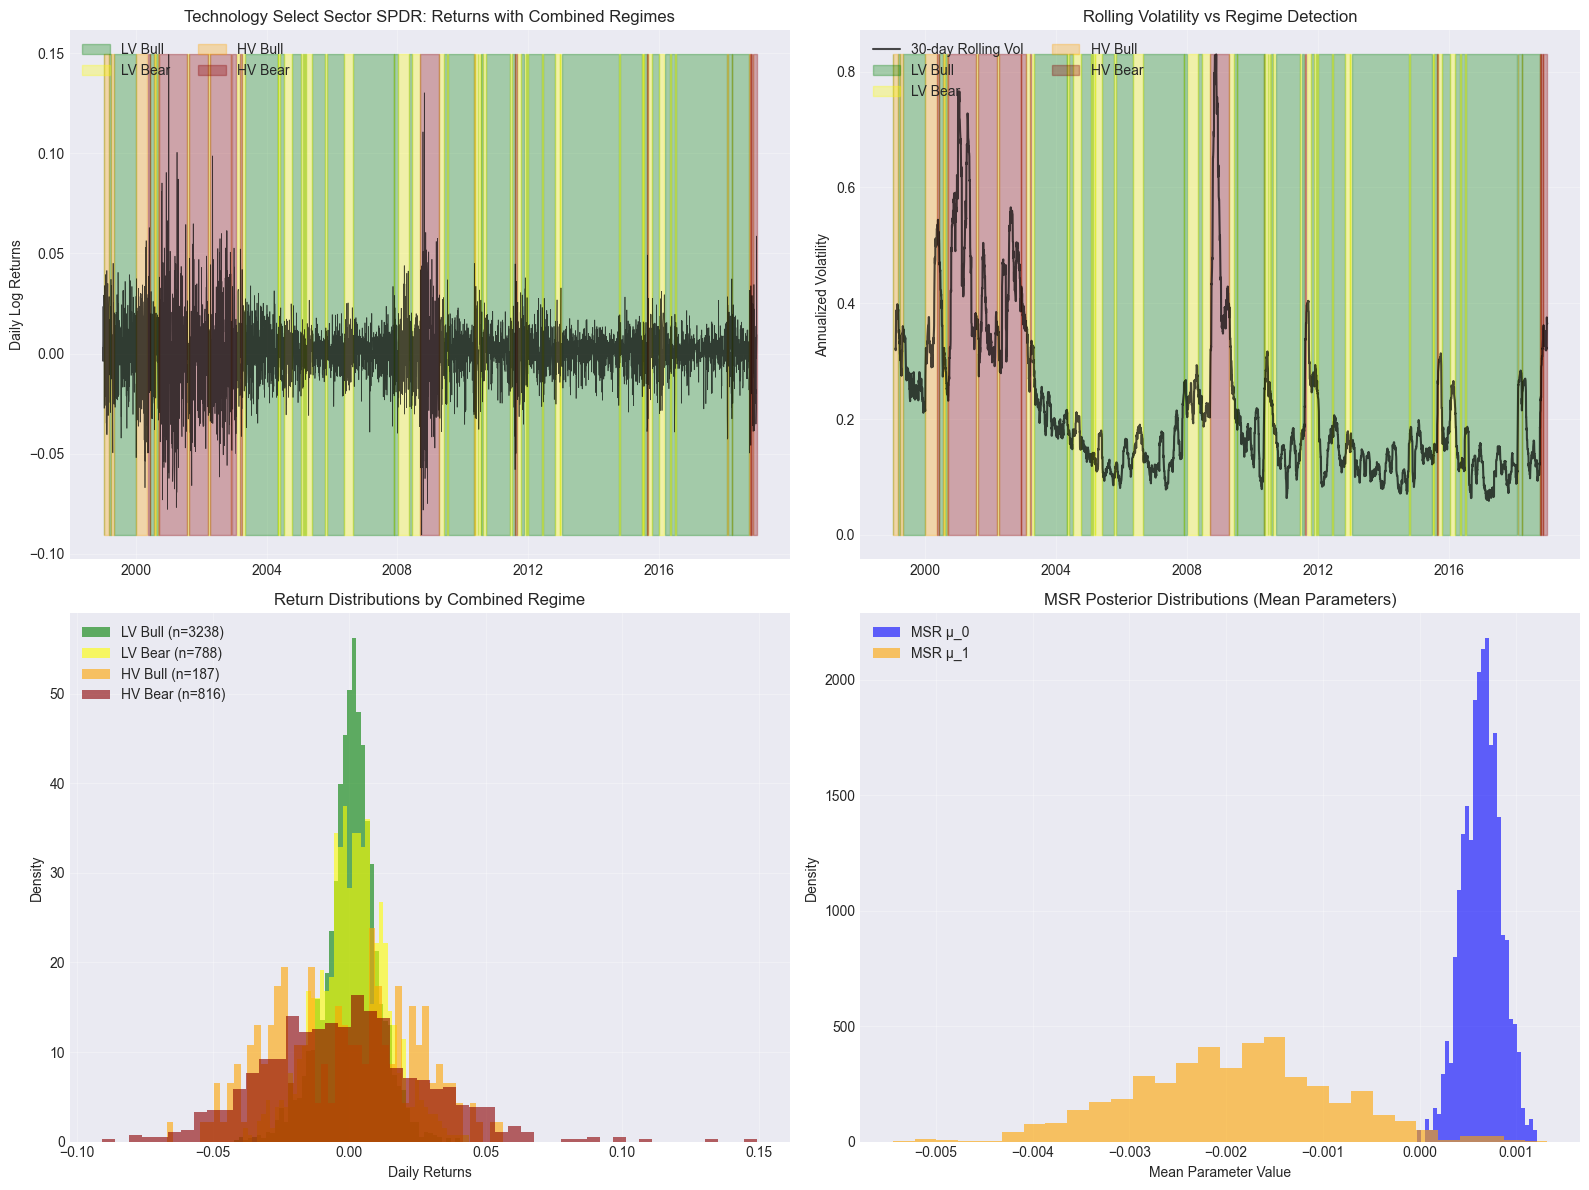


KAMA+MSR MODEL DIAGNOSTICS - TECHNOLOGY SELECT SECTOR SPDR

Combined Model Fit Statistics:
Log-Likelihood: 14460.06
Average Log-Likelihood: 2.87

KAMA Tracking Error (vs returns): 0.015945
KAMA Efficiency Ratio (mean): 0.3639

Regime Stability:
  Total regime changes: 101
  Average regime duration: 49.4 periods
  Change frequency: 2.01%


In [4]:
def load_and_analyze_KAMA_MSR_model(asset_name: str, n_regimes: int, sub_folder: str, edte_sub_folder: str) -> None:
    pkl_file_path = f'saved_models/KAMA_MSR/{sub_folder}/{edte_sub_folder}/{asset_name}_KAMA-MSR_{n_regimes*2}-regimes.pkl'
    with open(pkl_file_path, 'rb') as f:
        loaded_model = pickle.load(f)

    print("="*80)
    print("LOADED MODEL INFORMATION")
    print("="*80)

    # ============================================================================
    # 2. ACCESS KAMA PARAMETERS
    # ============================================================================
    print("\n2. KAMA PARAMETERS:")
    print("-" * 40)
    print(f"KAMA n: {loaded_model.kama.n}")
    print(f"KAMA n_fast: {loaded_model.kama.n_fast}")
    print(f"    KAMA k_fast: {loaded_model.kama.k_fast:.6f}")
    print(f"KAMA n_slow: {loaded_model.kama.n_slow}")
    print(f"    KAMA k_slow: {loaded_model.kama.k_slow:.6f}")
    print(f"gamma: {loaded_model.gamma}")

    # ============================================================================
    # 3. ACCESS PRIORS (AFTER OPTIMIZATION)
    # ============================================================================
    print("\n3. MSR PRIORS:")
    print("-" * 40)

    # The priors used during model initialization
    priors = loaded_model.msr.priors
    for param, value in priors.items():
        print(f"{param}: {value}")

    # ============================================================================
    # 4. ACCESS MODEL CONFIGURATION
    # ============================================================================
    print("\n4. MODEL CONFIGURATION:")
    print("-" * 40)
    print(f"use_three_state_msr: {loaded_model.use_three_state_msr}")
    print(f"Number of combined regimes: {loaded_model.n_combined_regimes}")
    print(f"MSR n_regimes: {loaded_model.msr.n_regimes}")

    # ============================================================================
    # 5. CHECK DATA DIMENSIONS
    # ============================================================================
    print("\n5. DATA INFORMATION:")
    print("-" * 40)
    if loaded_model.prices is not None:
        print(f"Price data length: {len(loaded_model.prices)}")
        print(f"Return data length: {len(loaded_model.returns)}")
        print(f"Regime labels length: {len(loaded_model.regime_labels.dropna())}")
        print(f"Regime changes: {(loaded_model.regime_labels.diff() != 0).sum()}")

    # ============================================================================
    # 6. ACCESS MSR PARAMETERS (AFTER FITTING)
    # ============================================================================
    print("\n6. MSR PARAMETERS (Post-Fit):")
    print("-" * 40)
    print("MSR Means (μ):")
    for i, mean in enumerate(loaded_model.msr.means):
        print(f"  Regime {i}: {mean:.6f}")

    print("\nMSR Betas (β):")
    for i, beta in enumerate(loaded_model.msr.betas):
        print(f"  Regime {i}: {beta:.4f}")

    print("\nMSR Standard Deviations (σ):")
    for i, std in enumerate(loaded_model.msr.stds):
        print(f"  Regime {i}: {std:.6f}")

    print("\nMSR Transition Probabilities:")
    print("          To Regime:")
    print("From      0       1" + ("       2" if loaded_model.msr.n_regimes == 3 else ""))
    print("Regime")
    for i in range(loaded_model.msr.n_regimes):
        row = f"  {i}    "
        for j in range(loaded_model.msr.n_regimes):
            row += f"  {loaded_model.msr.transition_probs[i,j]:.3f}"
        print(row)


    # ============================================================================
    # 7. RUN ANALYSIS ON LOADED MODEL
    # ============================================================================
    print("\n7. RUNNING FULL ANALYSIS ON LOADED MODEL...")
    loaded_model.analyze_results(data_name=asset_name)
    regime_duration_stats = loaded_model.analyze_regime_durations()
    print("\nRegime Duration Statistics:")
    print(regime_duration_stats)
    loaded_model.regime_characteristics(data_name=asset_name)
    transition_results = loaded_model.regime_transition_analysis(in_depth=False)
    loaded_model.plot_regimes(data_name=asset_name)
    # loaded_model.plot_regime_duration_distribution()
    loaded_model.plot_comprehensive_analysis(data_name=asset_name)
    loaded_model.diagnostics(data_name=asset_name, trace_plots=False)
    
    return loaded_model, transition_results

asset_name = 'Technology Select Sector SPDR'
n_regimes = 2
sub_folder = 'us_equity'
edte_sub_folder = datetime(2018, 12, 31).strftime('%Y%m%d')
loaded_model, transition_results = load_and_analyze_KAMA_MSR_model(asset_name, n_regimes, sub_folder, edte_sub_folder)

In [5]:
level1_transition_matrix = transition_results[1]['transition_probabilities']\
    .rename(columns={0: 'Low Vol Bull', 1: 'Low Vol Bear', 2: 'High Vol Bull', 3: 'High Vol Bear'},
            index={0: 'Low Vol Bull', 1: 'Low Vol Bear', 2: 'High Vol Bull', 3: 'High Vol Bear'})\
            .rename_axis('From').rename_axis('To', axis=1).round(4) * 100

level1_transition_matrix

To,Low Vol Bull,Low Vol Bear,High Vol Bull,High Vol Bear
From,,,,
Low Vol Bull,98.82,0.87,0.31,0.00
Low Vol Bear,4.06,95.43,0.00,0.51
High Vol Bull,3.31,0.55,91.71,4.42
High Vol Bear,0.00,0.86,0.49,98.65


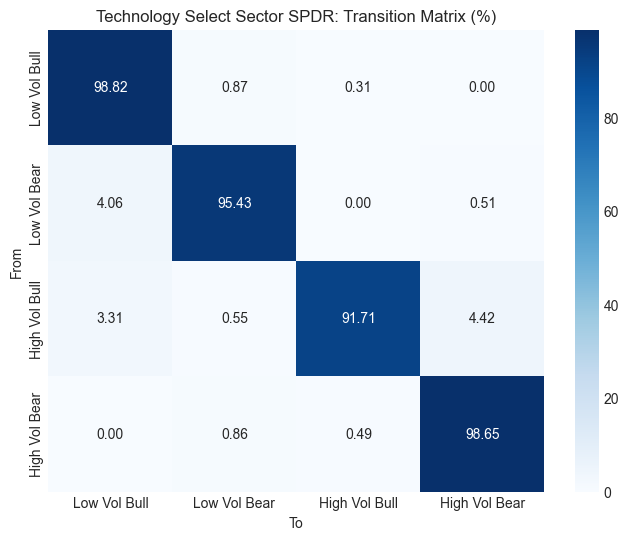

In [6]:
# Heatmap of level 1 transition matrix
plt.figure(figsize=(8, 6))
sns.heatmap(level1_transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"{asset_name}: Transition Matrix (%)")
plt.show()

In [7]:
level2_transition_matrix = transition_results[1]['level_two_transition_probabilities']\
    .rename_axis('From').rename_axis('To', axis=1).round(3) * 100

level2_transition_matrix

To,Low Vol Bull,Low Vol Bear,High Vol Bull,High Vol Bear
From,,,,
Low Vol Bull → Low Vol Bear (n=28),96.4,0.0,0.0,3.6
Low Vol Bull → High Vol Bull (n=10),40.0,10.0,0.0,50.0
Low Vol Bear → Low Vol Bull (n=32),0.0,84.4,15.6,0.0
Low Vol Bear → High Vol Bear (n=4),0.0,75.0,25.0,0.0
High Vol Bull → Low Vol Bull (n=6),0.0,16.7,83.3,0.0
High Vol Bull → Low Vol Bear (n=1),100.0,0.0,0.0,0.0
High Vol Bull → High Vol Bear (n=7),0.0,57.1,42.9,0.0
High Vol Bear → Low Vol Bear (n=7),57.1,0.0,0.0,42.9
High Vol Bear → High Vol Bull (n=4),25.0,0.0,0.0,75.0


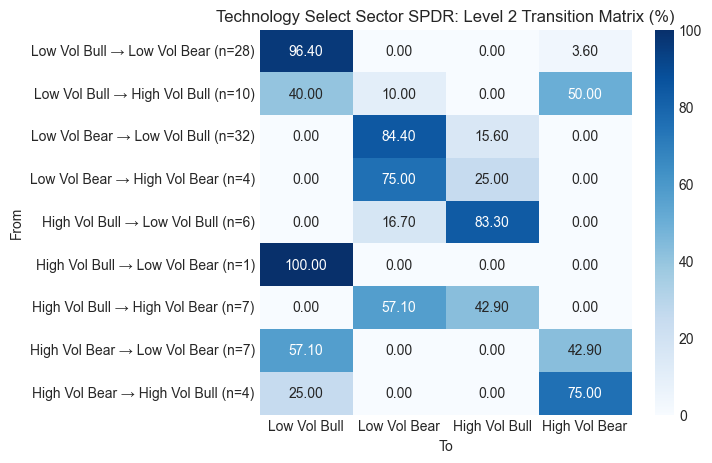

In [8]:
# Heatmap of Level 2 transition matrix
plt.figure(figsize=(6, 5))
sns.heatmap(level2_transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"{asset_name}: Level 2 Transition Matrix (%)")
plt.show()